In [4]:
from ase import units
from ase.io import read, write
from ase import Atoms
import numpy as np
from numpy import linalg as LA

import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [5]:
file='predicted_train.xyz'

# Parity plot

/home/mibianchi/ase_env/lib/python3.7/site-packages/ipykernel_launcher.py:74: RuntimeWarning: divide by zero encountered in double_scalars


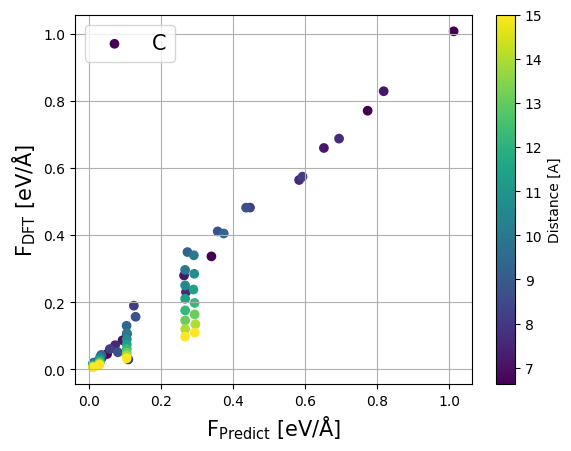

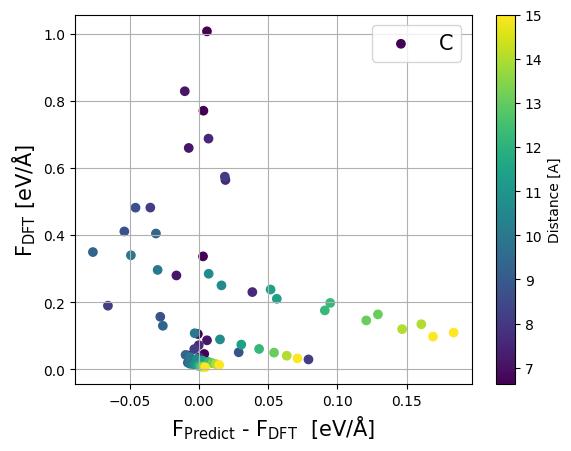

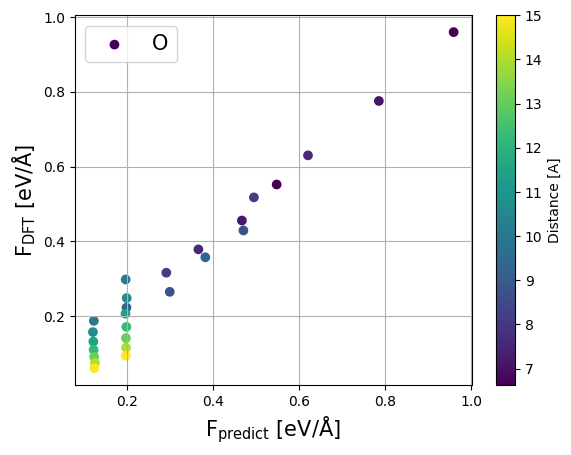

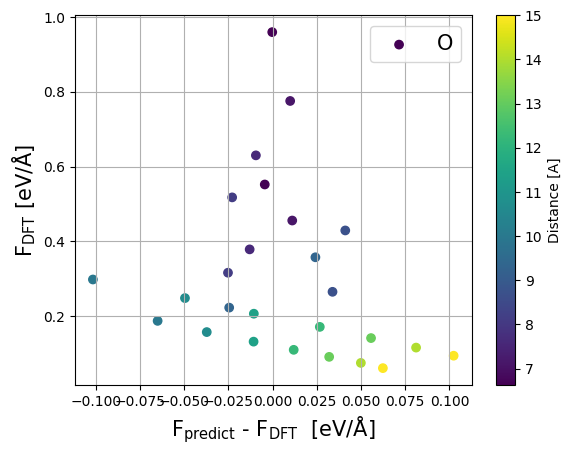

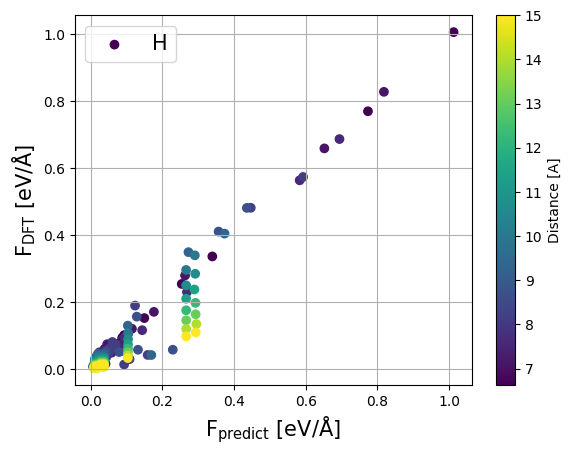

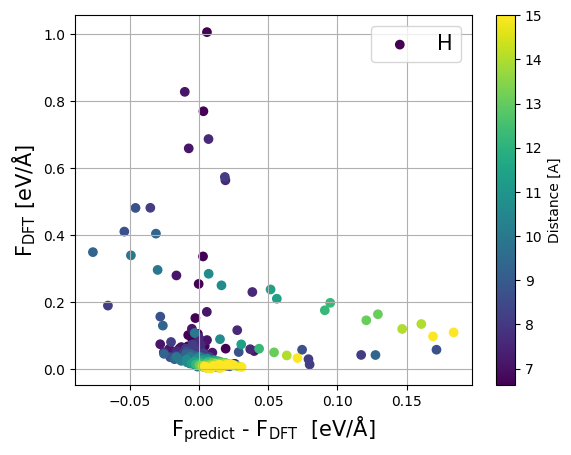

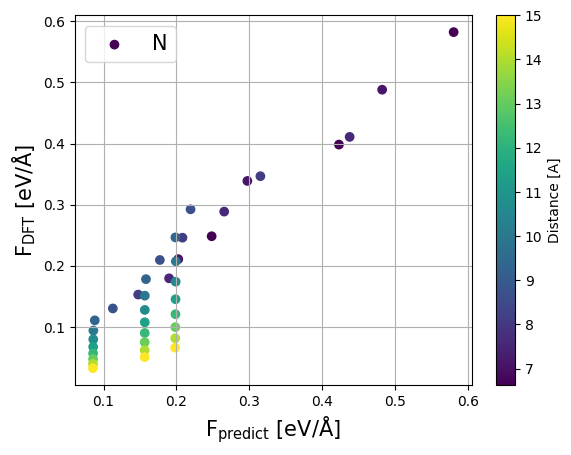

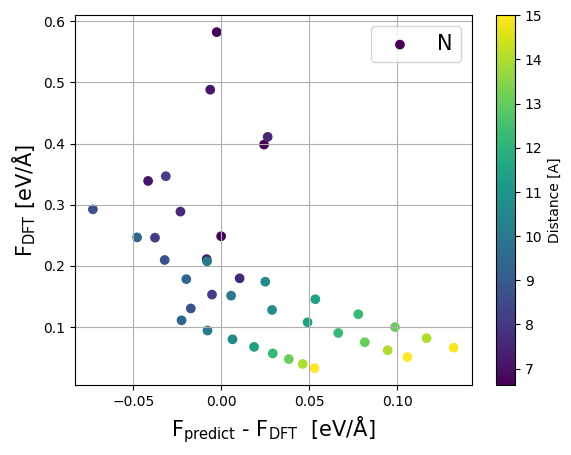

In [6]:
MD= read(file,index=':',format='extxyz')

C_F_predict=[]
C_F_truth=[]
O_F_predict=[]
O_F_truth=[]
H_F_predict=[]
H_F_truth=[]
N_F_predict=[]
N_F_truth=[]
C_max_F_error=[]
O_max_F_error=[]
H_max_F_error=[]
N_max_F_error=[]
C_F_ave_error=[]
O_F_ave_error=[]
H_F_ave_error=[]
N_F_ave_error=[]
distance_C=[]
distance_O=[]
distance_H=[]
distance_N=[]

for i in range(0,len(MD)):
    snap = MD[i]
    symbol=snap.get_chemical_symbols()
    atomic_number=snap.get_atomic_numbers()
    distance=snap.info["distance"]
    
    energy_truth=snap.info["DFT_energy"]
    forces_truth=snap.arrays["DFT_forces"]
    
    energy_predict=snap.info["LR_energy"]
    forces_predict=snap.arrays["LR_forces"]

    temp_max_C=0
    temp_max_O=0
    temp_max_H=0
    temp_max_N=0
    temp_ave_C=0
    temp_ave_O=0
    temp_ave_H=0
    temp_ave_N=0

    for j in range(0,len(symbol)):
        if symbol[j]=='C':#C=1
            C_F_predict.append(forces_predict[j])
            C_F_truth.append(forces_truth[j])
            distance_C.append(distance)
            temp_max_C=max(temp_max_C,max(forces_predict[j]-forces_truth[j]))
            temp_ave_C=temp_ave_C+(((forces_truth[j,0]-forces_predict[j,0])**2+(forces_truth[j,1]-forces_predict[j,1])**2+(forces_truth[j,2]-forces_predict[j,2])**2)**0.5)**4# modulo di errore su forze
        if symbol[j]=='N':
            N_F_predict.append(forces_predict[j])
            N_F_truth.append(forces_truth[j])
            distance_N.append(distance)
            temp_max_N=max(temp_max_N,max(forces_predict[j]-forces_truth[j]))
            temp_ave_N=temp_ave_N+(((forces_truth[j,0]-forces_predict[j,0])**2+(forces_truth[j,1]-forces_predict[j,1])**2+(forces_truth[j,2]-forces_predict[j,2])**2)**0.5)**4# modulo di errore su forze
        elif symbol[j]=='O': #O=3 
            O_F_predict.append(forces_predict[j])
            O_F_truth.append(forces_truth[j])
            distance_O.append(distance)
            temp_max_O=max(temp_max_O,max(forces_predict[j]-forces_truth[j]))
            temp_ave_O=temp_ave_O+(((forces_truth[j,0]-forces_predict[j,0])**2+(forces_truth[j,1]-forces_predict[j,1])**2+(forces_truth[j,2]-forces_predict[j,2])**2)**0.5)**4
        else:
            H_F_predict.append(forces_predict[j])
            H_F_truth.append(forces_truth[j]) 
            distance_H.append(distance)
            temp_max_H=max(temp_max_H,max(forces_predict[j]-forces_truth[j]))
            temp_ave_H=temp_ave_H+(((forces_truth[j,0]-forces_predict[j,0])**2+(forces_truth[j,1]-forces_predict[j,1])**2+(forces_truth[j,2]-forces_predict[j,2])**2)**0.5)**4

    C_max_F_error.append(temp_max_C)
    O_max_F_error.append(temp_max_O)
    H_max_F_error.append(temp_max_H)
    C_F_ave_error.append((temp_ave_C/len(np.argwhere(atomic_number==29)))**0.25)
    O_F_ave_error.append((temp_ave_O/len(np.argwhere(atomic_number==8)))**0.25)
    H_F_ave_error.append((temp_ave_H/len(np.argwhere(atomic_number==1)))**0.25)
    
# C
norm_predict=np.zeros(len(C_F_predict))
norm_truth=np.zeros(len(C_F_predict))
for i in range(0,len(C_F_predict)):
    norm_predict[i]=LA.norm(C_F_predict[i])
    norm_truth[i]=LA.norm(C_F_truth[i])

plt.scatter(norm_predict,norm_truth,c=distance_C, cmap='viridis',label='C')
plt.colorbar(label='Distance [A]')
#plt.plot([0,0.015],[0,0.015],'k--')
params = {'mathtext.default': 'regular' } 
plt.rcParams.update(params)
plt.grid()
plt.xlabel('F$_{Predict}$ [eV/$\AA$]',fontsize=15)
plt.ylabel('F$_{DFT}$ [eV/$\AA$]',fontsize=15)
plt.legend(fontsize=15)
plt.show()

plt.scatter(norm_predict-norm_truth,norm_truth,c=distance_C, cmap='viridis',label='C')
plt.colorbar(label='Distance [A]')
params = {'mathtext.default': 'regular' } 
plt.rcParams.update(params)
plt.grid()
plt.xlabel('F$_{Predict}$ - F$_{DFT}$  [eV/$\AA$]',fontsize=15)
plt.ylabel('F$_{DFT}$ [eV/$\AA$]',fontsize=15)
plt.legend(fontsize=15)
plt.show()

# O
norm_predict=np.zeros(len(O_F_predict))
norm_truth=np.zeros(len(O_F_predict))
for i in range(0,len(O_F_predict)):
    norm_predict[i]=LA.norm(O_F_predict[i])
    norm_truth[i]=LA.norm(O_F_truth[i])

plt.scatter(norm_predict,norm_truth,c=distance_O, cmap='viridis',label='O')
plt.colorbar(label='Distance [A]')
params = {'mathtext.default': 'regular' } 
plt.rcParams.update(params)
plt.grid()
plt.xlabel('F$_{predict}$ [eV/$\AA$]',fontsize=15)
plt.ylabel('F$_{DFT}$ [eV/$\AA$]',fontsize=15)
plt.legend(fontsize=15)
plt.show()

plt.scatter(norm_predict-norm_truth,norm_truth,c=distance_O, cmap='viridis',label='O')
plt.colorbar(label='Distance [A]')
params = {'mathtext.default': 'regular' } 
plt.rcParams.update(params)
plt.grid()
plt.xlabel('F$_{predict}$ - F$_{DFT}$  [eV/$\AA$]',fontsize=15)
plt.ylabel('F$_{DFT}$ [eV/$\AA$]',fontsize=15)
plt.legend(fontsize=15)
plt.show()

# H
norm_predict=np.zeros(len(H_F_predict))
norm_truth=np.zeros(len(H_F_predict))
for i in range(0,len(H_F_predict)):
    norm_predict[i]=LA.norm(H_F_predict[i])
    norm_truth[i]=LA.norm(H_F_truth[i])

plt.scatter(norm_predict,norm_truth,c=distance_H, cmap='viridis',label='H')
plt.colorbar(label='Distance [A]')
params = {'mathtext.default': 'regular' } 
plt.rcParams.update(params)
plt.grid()
plt.xlabel('F$_{predict}$ [eV/$\AA$]',fontsize=15)
plt.ylabel('F$_{DFT}$ [eV/$\AA$]',fontsize=15)
plt.legend(fontsize=15)
plt.show()

plt.scatter(norm_predict-norm_truth,norm_truth,c=distance_H, cmap='viridis',label='H')
plt.colorbar(label='Distance [A]')
params = {'mathtext.default': 'regular' } 
plt.rcParams.update(params)
plt.grid()
plt.xlabel('F$_{predict}$ - F$_{DFT}$  [eV/$\AA$]',fontsize=15)
plt.ylabel('F$_{DFT}$ [eV/$\AA$]',fontsize=15)
plt.legend(fontsize=15)
plt.show()

# N
norm_predict=np.zeros(len(N_F_predict))
norm_truth=np.zeros(len(N_F_predict))
for i in range(0,len(N_F_predict)):
    norm_predict[i]=LA.norm(N_F_predict[i])
    norm_truth[i]=LA.norm(N_F_truth[i])

plt.scatter(norm_predict,norm_truth,c=distance_N, cmap='viridis',label='N')
plt.colorbar(label='Distance [A]')
params = {'mathtext.default': 'regular' } 
plt.rcParams.update(params)
plt.grid()
plt.xlabel('F$_{predict}$ [eV/$\AA$]',fontsize=15)
plt.ylabel('F$_{DFT}$ [eV/$\AA$]',fontsize=15)
plt.legend(fontsize=15)
plt.show()

plt.scatter(norm_predict-norm_truth,norm_truth,c=distance_N, cmap='viridis',label='N')
plt.colorbar(label='Distance [A]')
params = {'mathtext.default': 'regular' } 
plt.rcParams.update(params)
plt.grid()
plt.xlabel('F$_{predict}$ - F$_{DFT}$  [eV/$\AA$]',fontsize=15)
plt.ylabel('F$_{DFT}$ [eV/$\AA$]',fontsize=15)
plt.legend(fontsize=15)
plt.show()